In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from gurobipy import *
from sklearn.cluster import KMeans
import matplotlib.cm as cm
os.chdir("/Users/michael/Desktop/Dissertation")
print(os.getcwd())
np.random.seed(42)

from scenarioswithWind import * 
from drMSPModel_penalty_enumeratedDART import * 
from plottingFuncsMSP import * 
from generateDAProfilesEnumerated import * 
from GenerateRTProfilesFlex import * 
from reboundanalysis import * 


/Users/michael/Desktop/Dissertation


## Mathematical Formulation

### Sets
\begin{align*}
J &\quad \text{DA fixed DR resources} \\
L &\quad \text{RT DR resources} \\
K &\quad \text{start-time variants DA Resources}\\
I &\quad \text{start-time variants RT Resources}\\
T &\quad \text{time periods} \\
S &\quad \text{scenarios} \\
N &\quad \text{noon nodes}
\end{align*}

### Parameters
\begin{align*}
L_{ts} &\quad \text{base load at time } t \text{ in scenario } s \\
\delta_{jkt} &\quad \text{response profile of DA fixed DR resource } j  \text{ under start-variant } k\text{ at time } t  \\
\rho_{lit} &\quad \text{zero-padded response profile of RT resource } l \text{ under start-variant } i \text{ at time } t \\
DA^{max} &\quad \text{max number of DA fixed DR resources activated} \\
RT^{max} &\quad \text{max number of RT resources activated per node} \\
rampLimit &\quad \text{cap on the 3-period rolling absolute ramp, active for } t \geq t_{mid} \\
t_{mid} &\quad \text{noon time index from which the rolling ramp constraint applies} \\
n(s) &\quad \text{noon node associated with scenario } s \\ 
\lambda^{ramp} &\quad \text{penalty weight on ramp-limit breaches } 
\end{align*}

### Variables
\begin{align*}
L_{ts}^{net} &\quad \text{net load at time } t \text{ in scenario } s \text{ after DR impact}\\
\Delta L_{jt} &\quad \text{load change by DA fixed DR resource } j \text{ at time } t \\
\Delta L^{RT}_{l,t,s} &\quad \text{load change by RT resource } l \text{ at time } t \text{ in scenario } s \\
u_{jk} &\quad \text{binary, 1 if DA fixed DR resource } j \text{ is activated with start-variant } k \\
u^{RT}_{l,i,n} &\quad \text{binary, 1 if RT resource } l \text{ is activated with start-variant } i \text{ at node } n \\
\pi_s &\quad \text{auxiliary variable for peak net load in scenario } s \\
r_{ts} &\quad \text{auxiliary variable for absolute ramp between } t-1 \text{ and } t \text{ in scenario } s \\
v_{ts}^{ramp}  &\quad \text{slack variable for excess ramping beyond limit at time } t \text{ in scenario } s
\end{align*}

### Objective Function
Minimise the Peak and Ramping and Penalty Violations 
\begin{equation}
\min \quad \sum_s P_s\, \pi_s \;+\; \sum_s P_s \sum_{t } r_{ts}  + \lambda^{ramp} \sum_s P_s \sum_{t >t_{mid}}v_{ts}^{ramp} 
\end{equation}


### Constraints

#### Net Load
\begin{equation}
L_{ts}^{\text{net}} = L_{ts} + \sum_j \Delta L_{jt} + \sum_l \Delta L^{RT}_{lts}
\qquad \forall\, t,\, s
\end{equation}

#### Peak Load
\begin{align}
\pi_s &\geq L_{ts}^{\text{net}}
\qquad \forall\, t,\, s
\end{align}

#### Absolute Ramping Between Periods
\begin{align}
r_{ts} &\geq L_{ts}^{\text{net}} - L_{t-1,s}^{\text{net}}
\qquad \forall\, t \geq 1,\, s \\
r_{ts} &\geq -\left(L_{ts}^{\text{net}} - L_{t-1,s}^{\text{net}}\right)
\qquad \forall\, t \geq 1,\, s
\end{align}
#### Rolling Ramp Limit
\begin{equation}
r_{ts} + r_{t-1,s} + r_{t-2,s} \leq rampLimit+ v_{ts}^{ramp}
\qquad \forall\, t \geq t_{mid},\, s \\
\end{equation}
#### DA DR Profile Constraints

\begin{align}
\Delta L_{jt} &= \sum_k\delta_{jkt}\, u_{jk}
\qquad \forall\, j,\, t
\end{align}
\begin{align}
\sum_k u_{jk} &\leq 1
\qquad \forall\, j
\end{align}

\begin{equation}
\sum_k\sum_j u_{jk} \leq DA^{max}
\end{equation}


#### RT DR Resources 
\begin{align}
\Delta L^{RT}_{lts} &=
\sum_{i \in I} \rho_{lit}\, u^{RT}_{lin(s)}
\qquad \forall\, l,\, t,\, s
\end{align}


\begin{align}
\sum_{i } u^{RT}_{lin} &\leq 1
\qquad \forall\, l,\, n
\end{align}

\begin{align}
\sum_l \sum_{i} u^{RT}_{lin} &\leq RT^{max}
\qquad \forall\, n
\end{align}

#### Domain Constraints
\begin{align}
\pi_s &\geq 0 \qquad \forall\, s \\
r_{ts} &\geq 0 \qquad \forall\, t,\, s \\
u_{jk} &\in \{0, 1\} \qquad \forall\, j, k \\
u^{RT}_{lin} &\in \{0, 1\} \qquad \forall\, l,\, i,\, n \\
v_{ts}^{ramp} &\geq 0\qquad \forall\, t \geq t_{mid},\, s
\end{align}

## Parameters 

In [6]:
# Scenario Generation Params 

n_noon_nodes =2
n_evening_per_node = 2
std_night = 0.02
n_scenarios = n_noon_nodes * n_evening_per_node


# Model Params

max_rt_DR =  5# Total number of RT DR resources 
max_da_DR = 3 # Total number of DA DR resources 
rampLimit = 35 # Rolling 3-period ramp limit
lambda_ramp = 50 # Penalty in obj for Violating Ramp Limit


### DA Fixed Profile

In [7]:
archetypes = {
    
    "1": {
        "hourly_raw": np.array([0, 0, -2, -4, -8, -12, -16, -12, -4, +10, +8, +4, 0]),
        "tau_minutes": 25,
        "noise_std": 0.05,
        "noise_phi": 0.75,
        "settle_tol": 0.02,
    },
    "2": {
        "hourly_raw": np.array([0, 0, -10, -16, -20, -20, -16, -10, +12, +12, +6, 0]),
        "tau_minutes": 6,
        "noise_std": 0.08,
        "noise_phi": 0.6,
        "settle_tol": 0.02,
    },
    "3": {
        "hourly_raw": np.array([0, -6, -10, -10, -10, -6,+8,  +2, 0]),
        "tau_minutes": 4,
        "noise_std": 0.08,
        "noise_phi": 0.5,
        "settle_tol": 0.02,
    },
    "4": {
        "hourly_raw": np.array([0, 0, -4, -8, -12, -12, -8, -4, +15, +8, +2, 0]),
        "tau_minutes": 30,
        "noise_std": 0.05,
        "noise_phi": 0.8,
        "settle_tol": 0.02,
    },
    "5": {
        "hourly_raw": np.array([0, 0, -16, -24, -24, -24, -24, -16, +25, +20, +15, +8, 0]),
        "tau_minutes": 8,
        "noise_std": 0.08,
        "noise_phi": 0.6,
        "settle_tol": 0.02,
    },
}


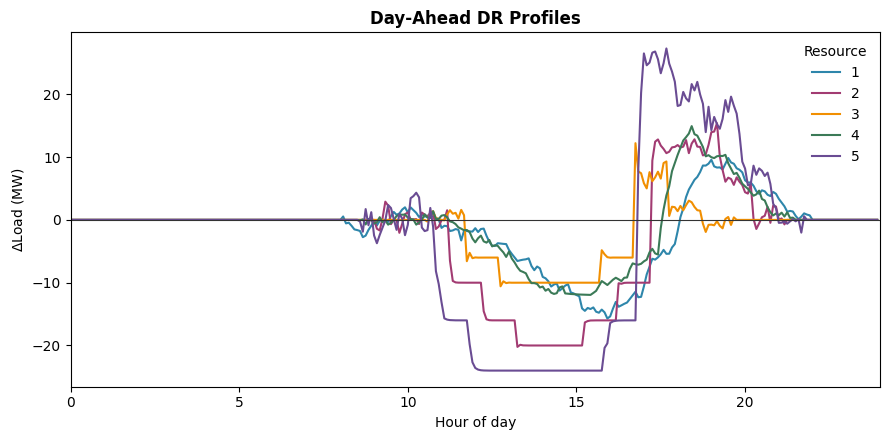

In [9]:
daResults = generateDAProfiles_Enumerated(archetypes, 
                                          start_step= 6 # length of steps between starts, eg 1 is every 5 min, 6 is every 30 min and 12 is everyhour                                        
                                         )

enumerated_profiles_DA = daResults["profiles"]
resource_names_DA = daResults["resource_names"]
valid_i_DA = daResults["valid_i"]
start_of_DA = daResults["start_of"]
n_starts_DA = daResults["n_starts"]


## Enumerate RT Profiles

In [10]:
T = 288

delta_raw = {
    "1": np.array([-10, -10, +6, +0]),
    "2": np.array([-6, -6, +4, +3,0]),
    "3": np.array([+4, -10, -10, +10, +4, 0]),
    "4": np.array([+4, +4, -11, -11, +6,0]),
    "5": np.array([-6, -6, -6, +6, +3, +2,0]),
    "6": np.array([-4, -4, +3, +2,  0]),
    "7": np.array([-8, -8, +6, +4, 0]),
    "8": np.array([-12, +7,0]),
}

TAU_MINUTES = {
    "1":     12,
    "2":     12,
    "3":     12,
    "4":     12,
    "5":     20,   
    "6":     6,    
    "7":     20,
    "8":     6,
}

OP_START, OP_END = T // 2, T  

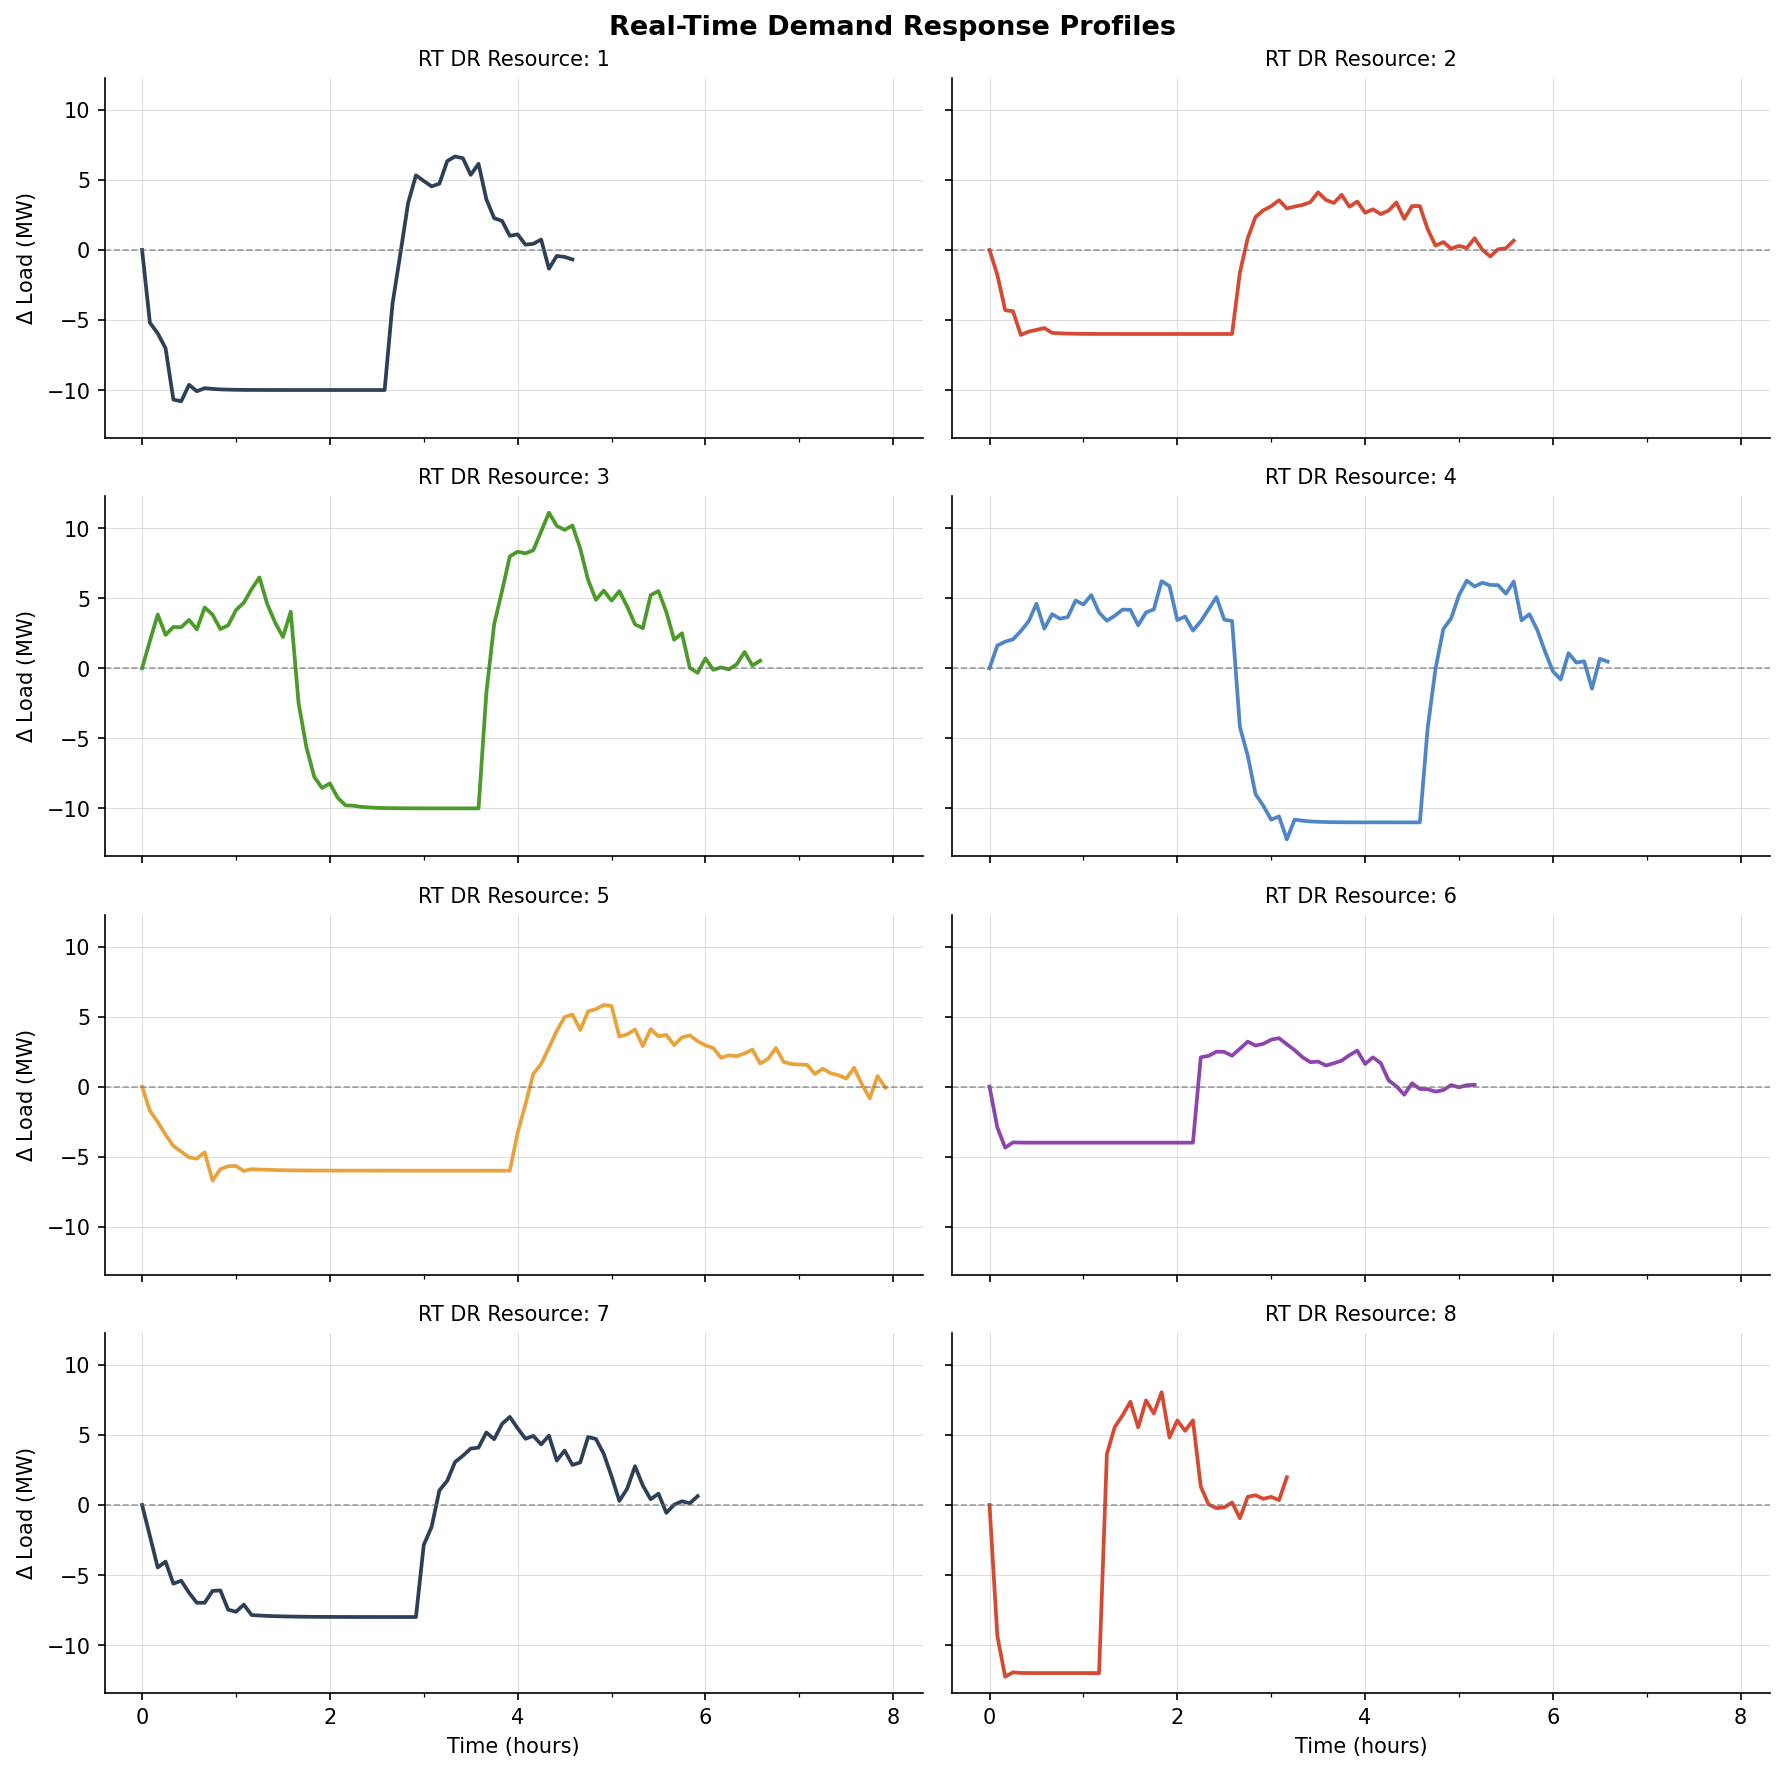

In [11]:
results = generateRTProfiles(
    delta_raw=delta_raw,
    tau_minutes=TAU_MINUTES,
    T=T,
    op_start=OP_START,
    op_end=OP_END,
    start_step= 1, # length of steps between starts, eg 1 is every 5 min, 6 is every 30 min and 12 is everyhour                                           )
    #hourly_interrupt_only=True, limit start to be exactly on the hour
    noise_std={"1": 0.1, "2": 0.08, "3": 0.08, "4": 0.08, "5": 0.08, "6":0.08, "7":0.08, "8": 0.08},
    noise_phi=0.1,
    settle_tol=0.02,
    noise_seed=42,
)

enumerated_profiles_RT = results["profiles"]
resource_names = results["resource_names"]
valid_i = results["valid_i"]
start_of = results["start_of"]
n_starts = results["n_starts"]

n_starts_max = max(n_starts.values())

## Scenarios 

### Base Scenario

/Users/michael/Desktop/Dissertation/scenarioswithWind.py:221: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])


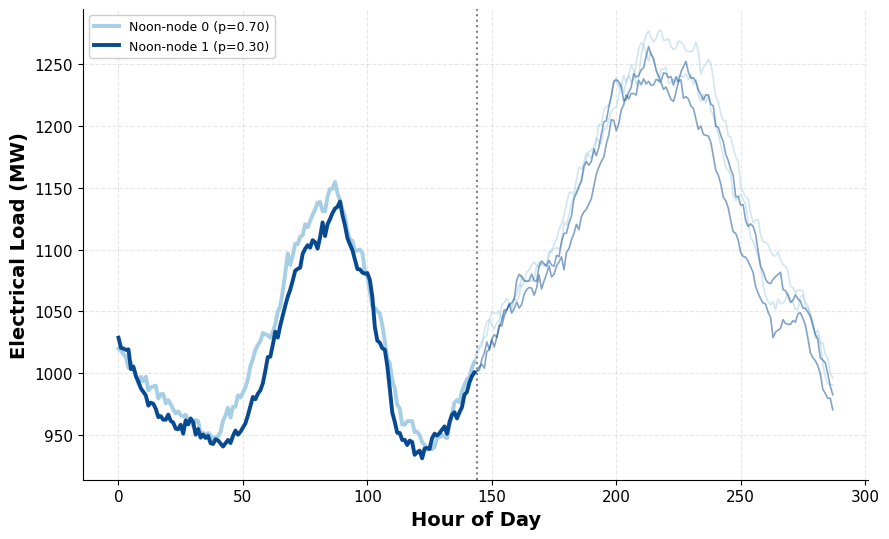

In [16]:
fullScenarios, scenarioProbs,scenarioToNode  = load_shifted_scenario_tree(n_noon_nodes, n_evening_per_node,
                        std_night,    
                        std_peak_shift= 0,
                        n_initial=3000,
                        csv_path='Pricing data/hrl_load_metered.csv',
                        granularity = '5min',
                        target_date='2025-12-10',
                        use_spikes = False)

### AI Spike Case

/Users/michael/Desktop/Dissertation/scenarioswithWind.py:221: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])


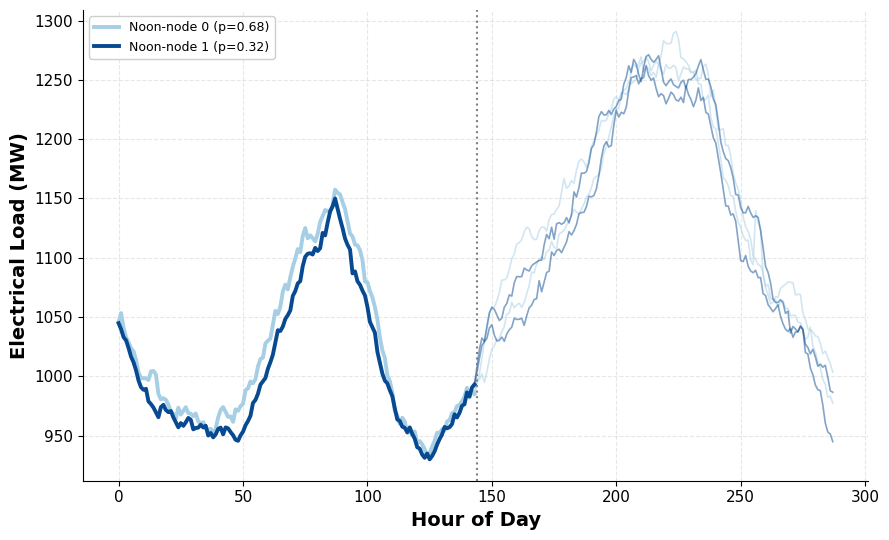

In [13]:
spike_kwargs_high = dict(
    rate=6.0, mag_frac_mean=0.08, mag_frac_std=0.03,
    hold_range=(1, 4), ramp_len=1, p_up=0.8, seed=42,
)

fullScenarios, scenarioProbs,scenarioToNode  = load_shifted_scenario_tree(n_noon_nodes, n_evening_per_node,
                        std_night,    
                        std_peak_shift= 0,
                        n_initial=3000,
                        csv_path='Pricing data/hrl_load_metered.csv',
                        granularity = '5min',
                        target_date='2025-12-10',
                        spike_kwargs =spike_kwargs_high )

### AI Spike + Peak Shifting 

/Users/michael/Desktop/Dissertation/scenarioswithWind.py:221: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])


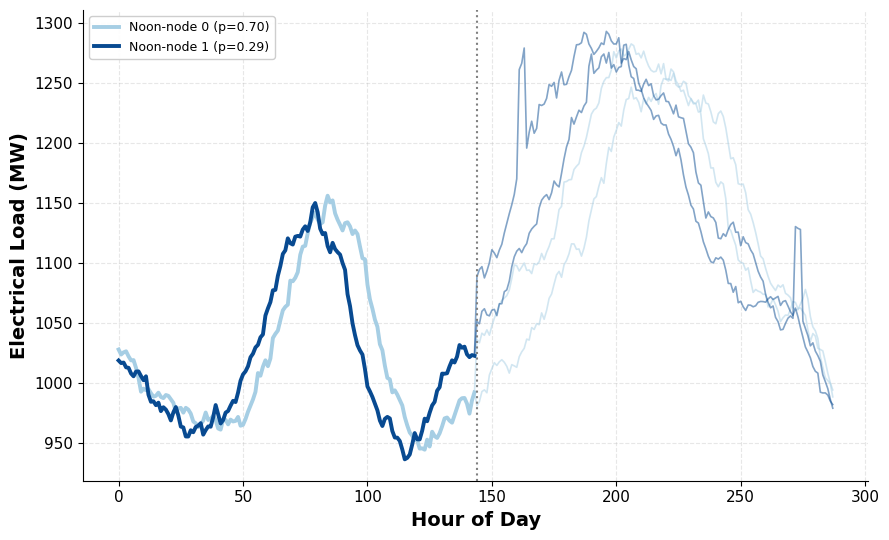

In [14]:
fullScenarios, scenarioProbs,scenarioToNode  = load_shifted_scenario_tree(n_noon_nodes, n_evening_per_node,
                        std_night,    
                        std_peak_shift= 15,
                        n_initial=3000,
                        csv_path='Pricing data/hrl_load_metered.csv',
                        granularity = '5min',
                        target_date='2025-12-10',
                        spike_kwargs =spike_kwargs_high )

### Net Load (Load - Wind)

/Users/michael/Desktop/Dissertation/scenarioswithWind.py:221: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])
/Users/michael/Desktop/Dissertation/scenarioswithWind.py:141: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wind['TimeStamp'] = pd.to_datetime(wind['TimeStamp'])


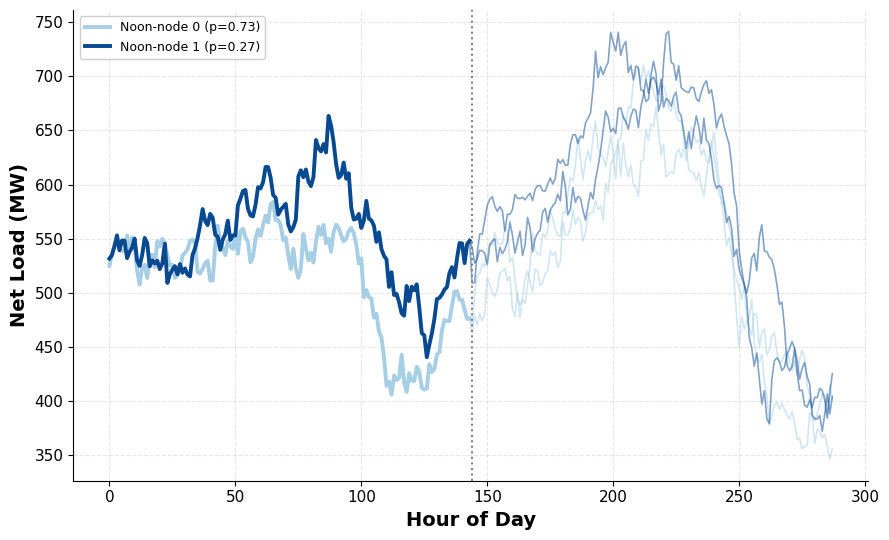

In [15]:
fullScenarios, scenarioProbs, scenarioToNode = load_shifted_scenario_tree(
    n_noon_nodes, n_evening_per_node,
    std_night,
    std_peak_shift=0,
    n_initial=3000,
    csv_path='Pricing data/hrl_load_metered.csv',
    granularity='5min',
    target_date='2025-12-10',
    spike_kwargs=spike_kwargs_high,
    use_spikes=False, 
    use_wind=True,
    wind_csv_path='Pricing data/wind_gen.csv',
    wind_kwargs=dict(target_penetration=0.5, sigma=0.1)
)

## Model 

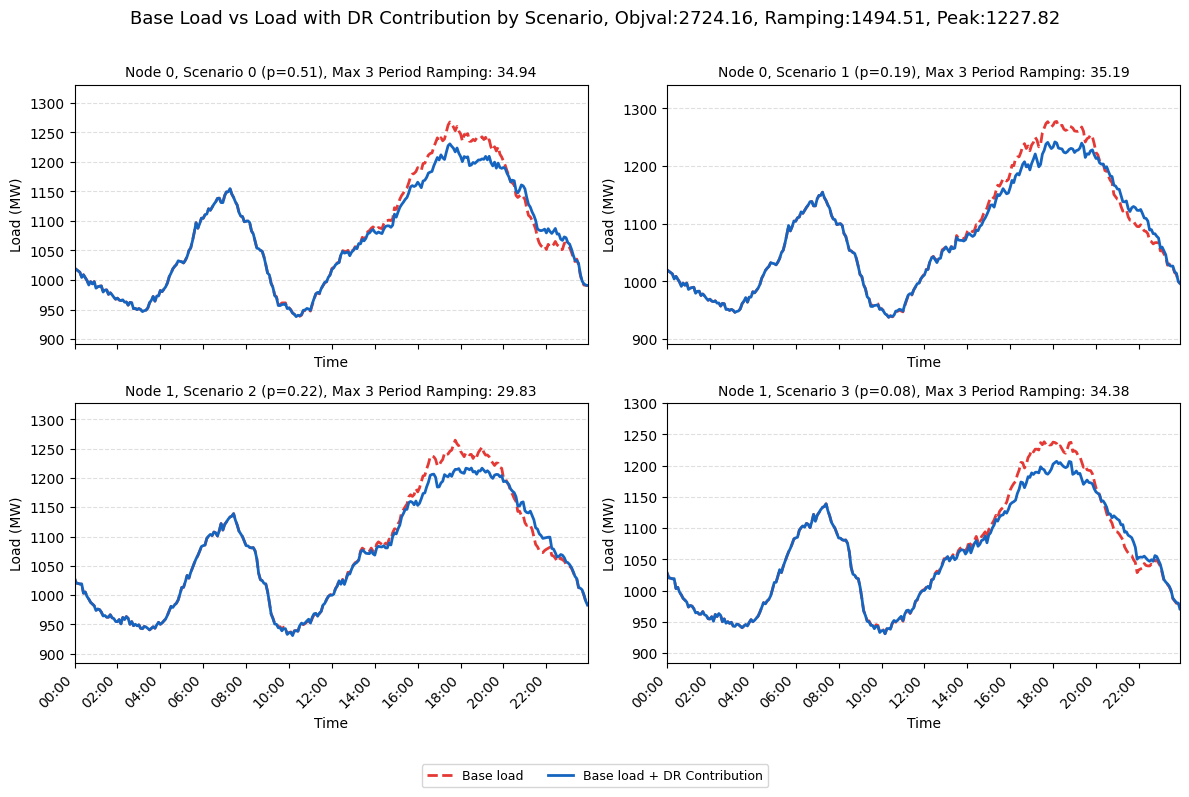

In [18]:
L_net_vals, delta_L_vals, delta_L_Fixed_vals, m, objval, r_vals, pi_vals, max_rolling_ramp, nodecount, u_vals, u_Fixed_vals = drMSPModel_Penalty(lambda_ramp, 
    max_rt_DR=max_rt_DR,
    max_da_DR=max_da_DR,
    scheduled_profiles=enumerated_profiles_DA,
    rt_fixed_profiles=enumerated_profiles_RT,
    n_noon_nodes=n_noon_nodes,
    n_evening_per_node=n_evening_per_node,
    scenario_probs=scenarioProbs,
    full_scenarios=fullScenarios,
    scenario_to_node=scenarioToNode,
    rampLimit=rampLimit,
    n_starts_max=n_starts_max,
    n_starts=n_starts,
    n_starts_da=n_starts_DA,)

plotLoadprofiles(L_net_vals, delta_L_vals, delta_L_Fixed_vals,
                         scenarioProbs, fullScenarios,
                         n_scenarios, objval,
                         r_vals, pi_vals, scenarioToNode, max_rolling_ramp)


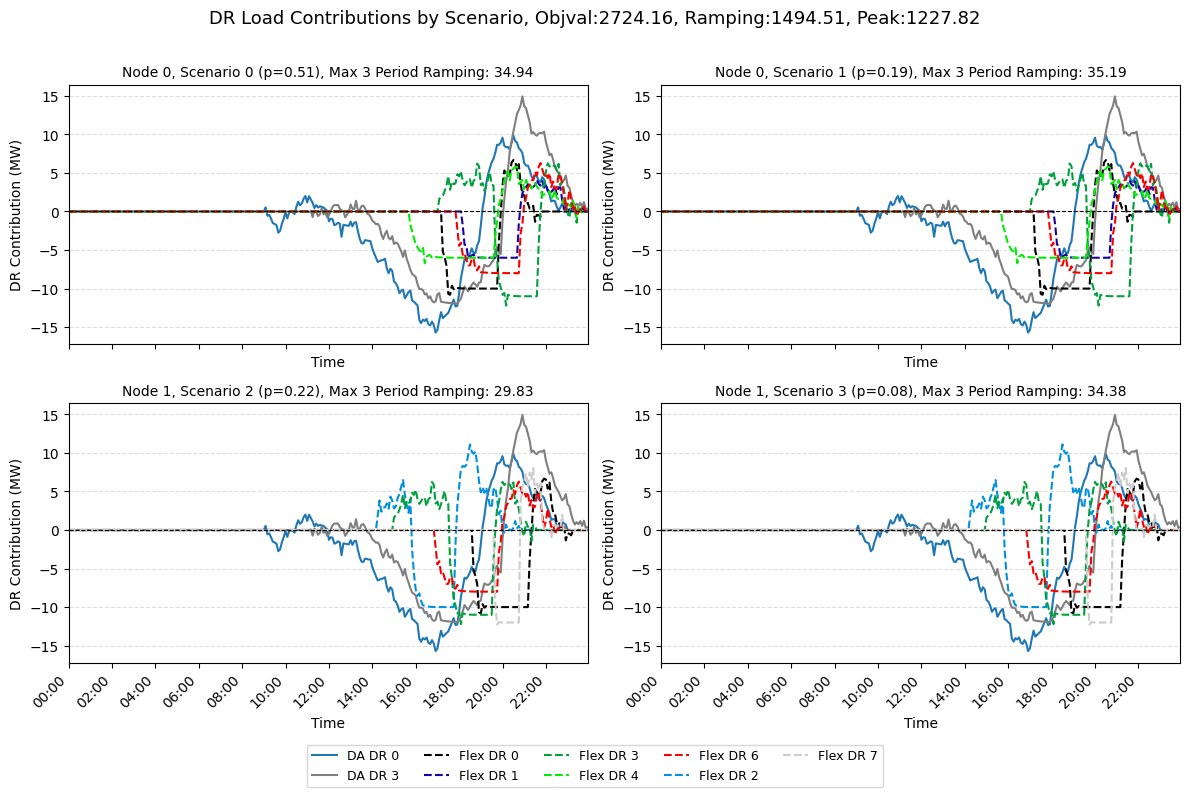

In [19]:
plotDRUsageForEnumerate(L_net_vals, delta_L_vals, delta_L_Fixed_vals,
                                 scenarioProbs, objval, r_vals, pi_vals,
                                 scenarioToNode, max_rolling_ramp, flex_shape_names=None)


/Users/michael/Desktop/Dissertation/reboundanalysis.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


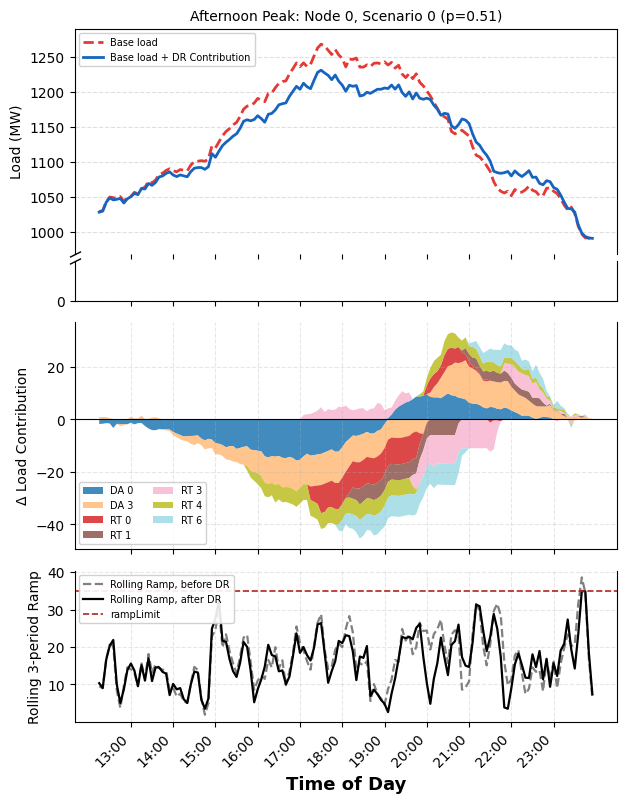

/Users/michael/Desktop/Dissertation/reboundanalysis.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


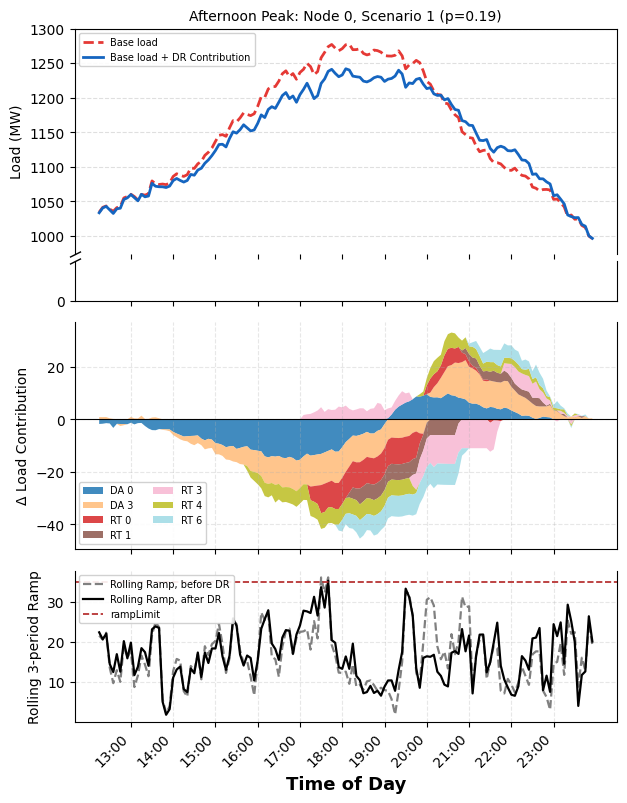

/Users/michael/Desktop/Dissertation/reboundanalysis.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


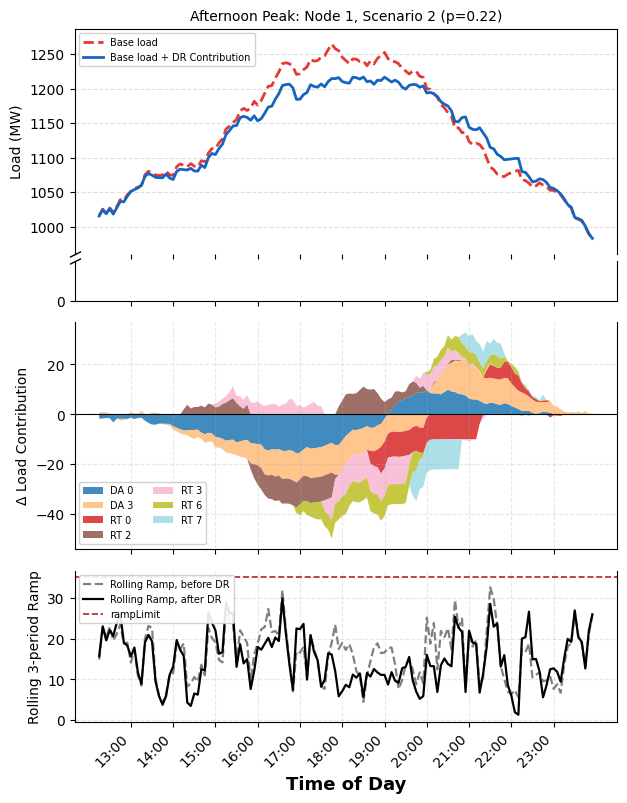

/Users/michael/Desktop/Dissertation/reboundanalysis.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


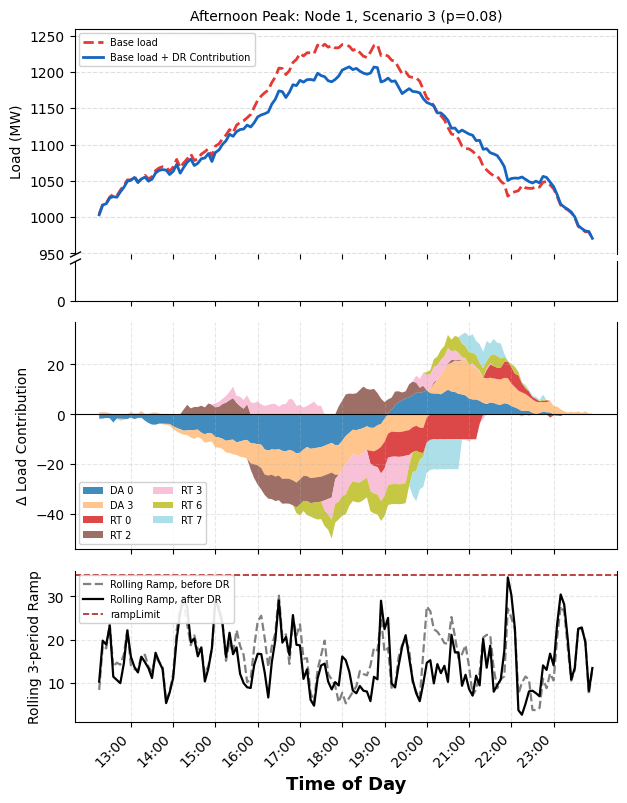

In [23]:
S = sorted(set(s for s, t in L_net_vals.keys()))
T = sorted(set(t for s, t in L_net_vals.keys()))
J = sorted(set(j for j, t in delta_L_vals.keys()))
K = sorted(set(k for n, k, t in delta_L_Fixed_vals.keys()))
L =  sorted(set(l for l, i, n in u_Fixed_vals.keys()))
series = build_resource_series(J, L, T, S, delta_L_vals, delta_L_Fixed_vals)

for s in S:
    plot_scenario_dispatch(s, T, series[s], r_vals, fullScenarios, rampLimit, OP_START,
                           L_net_vals, scenarioToNode, scenarioProbs,
                           format_time_axis=format_time_axis,
                           )